In [5]:
import os
os.environ["PATH"] = "/data/apps/extern/spack_on/gcc/9.3.0/texlive/20220321-oikenzl6gekq5lsohdm6jnnuj276s2ba/bin/x86_64-linux:" + os.environ.get("PATH", "")

import sys
from pathlib import Path

this_notebook = Path().resolve()

project_root = this_notebook.parents[0]

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

## Module imports

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LogNorm, SymLogNorm

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)

#import Zeus
import zeus21

#set up the CLASS cosmology
from classy import Class
import mcfit
from scipy.interpolate import interp1d
from tqdm import tqdm
from scipy.integrate import simps as simpson
from scipy.special import i0

## Get high-res $\rho$'s using memory-friendly method

In [7]:
UserParams = zeus21.User_Parameters(precisionboost=1.2)

# cosmo inputs from table 2 last column of 1807.06209, as 21cmFAST
ombh2 = 0.02242 
omch2 = 0.11933
tau_re = 0.0544
hLittle = 0.6766
ns = 0.9665
As = np.exp(3.047)*10**(-10.)

CosmoParams_input = zeus21.Cosmo_Parameters_Input(
    omegac = omch2, omegab = ombh2, h_fid = hLittle, As = As, ns = ns, tau_fid = tau_re, 
    USE_RELATIVE_VELOCITIES = True, Flag_emulate_21cmfast=False,
    ANISO_XI_ETA = False
    )

ClassCosmoVCB = Class()
ClassCosmoVCB.set({'omega_b': CosmoParams_input.omegab,
                   'omega_cdm': CosmoParams_input.omegac,
                   'h': CosmoParams_input.h_fid,
                   'A_s': CosmoParams_input.As,
                   'n_s': CosmoParams_input.ns,
                   'tau_reio': CosmoParams_input.tau_fid})
ClassCosmoVCB.set({'output':'vTk'})
ClassCosmoVCB.set({'P_k_max_1/Mpc':50.0, 'z_max_pk':12000})
ClassCosmoVCB.set({'gauge':'newtonian'})
ClassCosmoVCB.compute()

# Cosmo_Parameters = zeus21.Cosmo_Parameters(UserParams, CosmoParams_input, ClassyCosmo) 

In [8]:
from scipy.interpolate import interp1d

rlist = np.geomspace(0.1, 3000, 300)
klist, _dummy_ = mcfit.xi2P(rlist, l=0, lowring=True)(0*rlist, extrap=False)

# kmask = (klist >= 1e-3) & (klist <= 1.0)
# klist_trim = klist[kmask]
# Plist_trim = Plist[kmask]

z_drag = ClassCosmoVCB.get_current_derived_parameters(['z_d'])['z_d']
velTransFunc = ClassCosmoVCB.get_transfer(z_drag)

c_kms = 299792.458
k_vcb = velTransFunc['k (h/Mpc)'] * CosmoParams_input.h_fid
theta_b = velTransFunc['t_b']
theta_c = velTransFunc['t_cdm']
interp_func_theta_b = interp1d(k_vcb, theta_b, kind='cubic', fill_value="extrapolate")
interp_func_theta_c = interp1d(k_vcb, theta_c, kind='cubic', fill_value="extrapolate")
theta_b_dense = interp_func_theta_b(klist)
theta_c_dense = interp_func_theta_c(klist)

P_vcb = CosmoParams_input.As * (klist/0.05)**(CosmoParams_input.ns-1) * (theta_b_dense - theta_c_dense)**2/klist**2 * 2 * np.pi**2 / klist**3
sigma_vcb = np.sqrt(np.trapz(CosmoParams_input.As * (klist/0.05)**(CosmoParams_input.ns-1) / klist * (theta_b_dense - theta_c_dense)**2/klist**2, klist)) * c_kms


def Window(k,R):
        x = k * R
        return 3.0/x**2 * (np.sin(x)/x - np.cos(x))

In [9]:
# Original implementation (causes OOM)
# lengthRarray = len(rlist)
#
# windowR1 = Window(klist.reshape(lengthRarray, 1, 1), rlist.reshape(1, 1, lengthRarray))
# windowR2 = Window(klist.reshape(1, lengthRarray,1), rlist.reshape(1, 1, lengthRarray))
#
# psi_integrand_base = klist**2 / 2 / np.pi**2 * P_vcb * windowR1 * windowR2
# psi_integrand_base = psi_integrand_base[:, :, np.newaxis, :]
#
# psi_prefactor = 1 / (3 * (sigma_vcb/c_kms)**2)
#
# r_transpose = np.transpose([rlist])
# j0bessel = lambda x: np.sin(x)/x
# j2bessel = lambda x: (3 / x**2 - 1) * np.sin(x)/x - 3*np.cos(x)/x**2
#
# psi0 = 1 * psi_prefactor * np.trapz(psi_integrand_base * j0bessel(klist * r_transpose)[np.newaxis, np.newaxis, :, :],
#                                     klist, axis = -1)
# psi2 = -2 * psi_prefactor * np.trapz(psi_integrand_base * j2bessel(klist * r_transpose)[np.newaxis, np.newaxis, :, :],
#                                         klist, axis = -1)
#
# xi_para_RR_CF = psi0 + psi2
# xi_perp_RR_CF = psi0 - 0.5 * psi2
#
# # Normalize them
# xi_para_RR_CF /= np.max(np.abs(xi_para_RR_CF))
# xi_perp_RR_CF /= np.max(np.abs(xi_perp_RR_CF))

import gc

lengthRarray = len(rlist)

windowR1 = Window(klist.reshape(lengthRarray, 1, 1), rlist.reshape(1, 1, lengthRarray))
windowR2 = Window(klist.reshape(1, lengthRarray, 1), rlist.reshape(1, 1, lengthRarray))
psi_integrand_base = klist**2 / 2 / np.pi**2 * P_vcb * windowR1 * windowR2

psi_prefactor = 1 / (3 * (sigma_vcb / c_kms)**2)

r_transpose = np.transpose([rlist])
j0bessel = lambda x: np.sin(x) / x
j2bessel = lambda x: (3 / x**2 - 1) * np.sin(x) / x - 3 * np.cos(x) / x**2

# Trapezoid weights so each integration can be done as a weighted contraction.
dk = np.diff(klist)
trapz_w = np.empty_like(klist)
trapz_w[0] = 0.5 * dk[0]
trapz_w[-1] = 0.5 * dk[-1]
trapz_w[1:-1] = 0.5 * (klist[2:] - klist[:-2])

j0_grid = j0bessel(klist * r_transpose)
j2_grid = j2bessel(klist * r_transpose)

# Allocate only the final arrays to reduce peak memory.
xi_para_RR_CF = np.empty((lengthRarray, lengthRarray, lengthRarray), dtype=np.float64)
xi_perp_RR_CF = np.empty_like(xi_para_RR_CF)

for ir in range(lengthRarray):
    w0 = j0_grid[ir] * trapz_w
    w2 = j2_grid[ir] * trapz_w
    integ0 = psi_prefactor * np.tensordot(psi_integrand_base, w0, axes=([-1], [0]))
    integ2 = -2 * psi_prefactor * np.tensordot(psi_integrand_base, w2, axes=([-1], [0]))
    xi_para_RR_CF[:, :, ir] = integ0 + integ2
    xi_perp_RR_CF[:, :, ir] = integ0 - 0.5 * integ2

# Normalize them
xi_para_RR_CF /= np.max(np.abs(xi_para_RR_CF))
xi_perp_RR_CF /= np.max(np.abs(xi_perp_RR_CF))

# Drop large temporaries before moving to later cells to avoid kernel OOM.
del windowR1, windowR2, psi_integrand_base, dk, trapz_w, j0_grid, j2_grid
gc.collect()

0

findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.


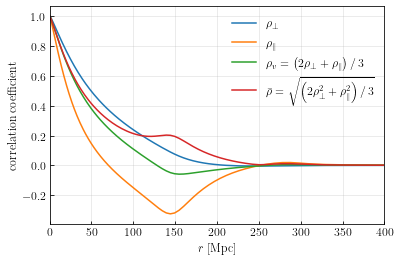

In [10]:
R1_choose = 0
R2_choose = 0

rho_para = xi_para_RR_CF[R1_choose, R2_choose, :]
rho_perp = xi_perp_RR_CF[R1_choose, R2_choose, :]
rho_orig = np.sqrt((2 * xi_perp_RR_CF[R1_choose, R2_choose, :]**2 + \
                   xi_para_RR_CF[R1_choose, R2_choose, :]**2) / 3)
rho_iso = (2 * rho_perp + rho_para) / 3

fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.plot(rlist, rho_perp, label=r'$\rho_{\perp}$')
ax.plot(rlist, rho_para, label=r'$\rho_{\parallel}$')
ax.plot(rlist, rho_iso, label=r'$\rho_v=\left(2\rho_\perp + \rho_\parallel\right)/\,3$')
ax.plot(rlist, rho_orig, label=r'$\bar\rho=\sqrt{\left(2\rho_{\perp}^2 + \rho_{\parallel}^2\right)/\,3}$')

ax.set_xlim(0, 400)
ax.set_xlabel(r'$r$ [Mpc]')
ax.set_ylabel(r'correlation coefficient')
ax.legend(frameon=False)
ax.tick_params(axis='both', which='major', direction='in')
ax.grid(True, which='both', alpha=0.3)

## Use these $\rho$'s to compute $\xi_U$

In [11]:
# Real run values from xi_U_comparison.ipynb
lambda1 = 1.1819690031628485
lambda2 = 1.1819690031628485

rho_para = xi_para_RR_CF
rho_perp = xi_perp_RR_CF

lambda_term = 4 * lambda1 * lambda2 / (1 + 2 * lambda1) / (1 + 2 * lambda2)
xi_U_highres = ((1 - lambda_term * rho_para**2) * (1 - lambda_term * rho_perp**2) ** 2) ** (-1/2) - 1
xi_U_highres_normalized = xi_U_highres / xi_U_highres.max()

### Compare with low-res versions

First retrieve the $\xi_U$'s computed in `xi_U_comparison.ipynb`:

In [12]:
import gc
from pathlib import Path

# Run a collection before loading additional arrays; this cell often follows large 3D allocations.
gc.collect()

candidate_files = [
    Path("output/xi_U_normalized_data.npz"),
    project_root / "aniso_tests" / "output" / "xi_U_normalized_data.npz",
]

for data_file in candidate_files:
    if data_file.exists():
        break
else:
    raise FileNotFoundError(
        "Could not find xi_U_normalized_data.npz in ./output or project_root/aniso_tests/output"
    )

saved = np.load(data_file)
r_saved = saved["rlist"]
xi_U_zeus_saved = saved["xi_U_zeus_normalized"]
xi_U_aniso_saved = saved["xi_U_aniso_normalized"]
xi_U_corrected_saved = saved["xi_U_corrected_normalized"]
saved.close()

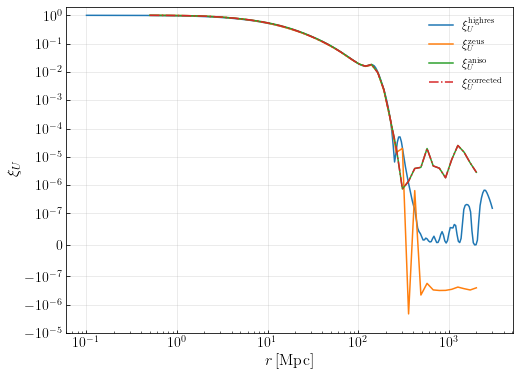

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rlist, xi_U_highres_normalized[0, 0, :], label=r'$\xi_U^{\mathrm{highres}}$')
ax.plot(r_saved, xi_U_zeus_saved, label=r"$\xi_U^{\mathrm{zeus}}$")
ax.plot(r_saved, xi_U_aniso_saved, label=r"$\xi_U^{\mathrm{aniso}}$")
ax.plot(r_saved, xi_U_corrected_saved, linestyle="-.", label=r"$\xi_U^{\mathrm{corrected}}$")
ax.set_ylim(-1e-5, 2)
ax.set_xscale("log")
ax.set_yscale('symlog', linthresh=1e-7)
ax.set_xlabel(r"$r\,[\mathrm{Mpc}]$", fontsize=16)
ax.set_ylabel(r"$\xi_U$", fontsize=16)
ax.legend(frameon=False)
ax.tick_params(axis="both", which="both", direction="in", labelsize=14)
ax.grid(True, alpha=0.3)

### Now plot high-res $\xi_U$'s with different $K$'s

In [14]:
K_values = [1/3, 2/3, 1.0]
R1_choose = 0
R2_choose = 0

def xi_U_with_K(rho_para, rho_perp, K):
    sqrt_term = (1 - K * rho_para**2) * (1 - K * rho_perp**2)**2
    return sqrt_term**(-0.5) - 1

# Use full high-resolution anisotropic rho fields.
rho_para_full = xi_para_RR_CF
rho_perp_full = xi_perp_RR_CF

# Define isotropic rho-bar from anisotropic components.
rho_bar_full = np.sqrt((2 * rho_perp_full**2 + rho_para_full**2) / 3)

xi_U_aniso_by_K = {}
xi_U_iso_by_K = {}

for K in K_values:
    xi_U_aniso_by_K[K] = xi_U_with_K(rho_para_full, rho_perp_full, K)
    xi_U_iso_by_K[K] = xi_U_with_K(rho_bar_full, rho_bar_full, K)

/home/yzhan629/Zeus21/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:7: RuntimeWarning: divide by zero encountered in power
  import sys


/home/yzhan629/Zeus21/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:30: RuntimeWarning: invalid value encountered in subtract
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.


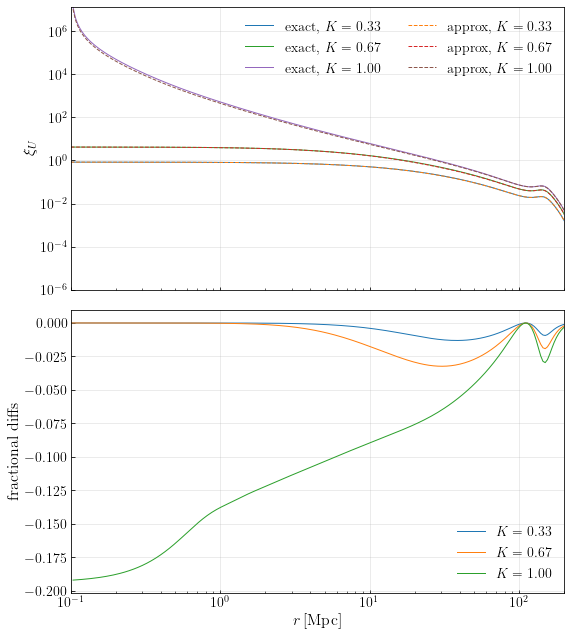

In [15]:
fig, axs = plt.subplots(
    2, 1, figsize=(8, 9), sharex=True, gridspec_kw={"height_ratios": [1, 1]}
 )

aniso_handles = []
iso_handles = []

for K in K_values:
    aniso_curve = xi_U_aniso_by_K[K][R1_choose, R2_choose, :]
    iso_curve = xi_U_iso_by_K[K][R1_choose, R2_choose, :]
    # aniso_curve = aniso_curve / np.max(aniso_curve)
    # iso_curve = iso_curve / np.max(iso_curve)

    h_aniso, = axs[0].plot(
        rlist,
        aniso_curve,
        lw=1,
        label=rf"exact, $K={K:.2f}$"
    )
    h_iso, = axs[0].plot(
        rlist,
        iso_curve,
        lw=1,
        ls="--",
        label=rf"approx, $K={K:.2f}$"
    )
    aniso_handles.append(h_aniso)
    iso_handles.append(h_iso)

    frac_diff = (iso_curve - aniso_curve) / aniso_curve
    axs[1].plot(rlist, frac_diff, lw=1, label=rf"$K={K:.2f}$")

# Column grouping: left = anisotropic, right = isotropic.
legend_handles = aniso_handles + iso_handles
legend_labels = [h.get_label() for h in legend_handles]

axs[0].set_xlim(1e-1, 200)
axs[0].set_ylim(1e-6, )
axs[0].set_xscale("log")
axs[0].set_yscale("log")
axs[0].set_ylabel(r"$\xi_U$", fontsize=16)
axs[0].legend(legend_handles, legend_labels, frameon=False, fontsize=14, ncol=2)
axs[0].tick_params(axis="both", which="both", direction="in", labelsize=14)
axs[0].grid(True, alpha=0.3)

axs[1].set_xscale("log")
axs[1].set_xlabel(r"$r\,[\mathrm{Mpc}]$", fontsize=16)
axs[1].set_ylabel(r"fractional diffs", fontsize=16)
axs[1].tick_params(axis="both", which="both", direction="in", labelsize=14)
axs[1].grid(True, alpha=0.3)
axs[1].legend(frameon=False, fontsize=14)

plt.tight_layout()

## PDF

In [19]:
def prefactor_N(rho_para, rho_perp):
    return (2 * np.pi)**3 * np.sqrt(1 - rho_para**2) * (1 - rho_perp**2)

def P_v_v(vbarsq, rho_para, rho_perp, v_1, v_2):
    '''
    Joint PDF of velocities v_1 and v_2.
    6 dimensional input seems like a handful.
    vbarsq is scalar.
    rho_para and rho_perp must have the same length (currently only support 1 dimension).
    v_1 and v_2 are 3D vectors, must have shape (n, 3).
    Not currently used
    '''
    N = prefactor_N(vbarsq, rho_para, rho_perp)

    # Broadcast to shape: (n_r, n_v, 3)
    N_bcast = N[:, np.newaxis, np.newaxis]
    rho_para_bcast = rho_para[:, np.newaxis, np.newaxis]
    rho_perp_bcast = rho_perp[:, np.newaxis, np.newaxis]
    v_1_bcast = v_1[np.newaxis, :, :]
    v_2_bcast = v_2[np.newaxis, :, :]

    v_1_perp = v_1_bcast[:, :, 0:1]
    v_2_perp = v_2_bcast[:, :, 0:1]
    v_1_z = v_1_bcast[:, :, 2]
    v_2_z = v_2_bcast[:, :, 2]

    exponent = - 1 / (2 * vbarsq) * (
                                    (v_1_z**2 + v_2_z**2 - 2 * rho_para_bcast * v_1_z * v_2_z) / (1 - rho_para_bcast**2) + 
                                    (v_1_perp**2 + v_2_perp**2 - 2 * rho_perp_bcast * np.inner(v_1_perp, v_2_perp)) / (1 - rho_perp_bcast**2)
                                    )
    return 1 / N_bcast * np.exp(exponent)

def P_X_Y(X, Y, vbarsq, rho_para, rho_perp, n_points=100):
    '''
    Joint PDF of X=v_1**2 and Y=v_2**2.
    vbarsq is scalar.
    rho_para and rho_perp must have the same length (currently only support 1 dimension)
    '''
    rho_para = np.array([rho_para]) if np.isscalar(rho_para) else np.array(rho_para)
    rho_perp = np.array([rho_perp]) if np.isscalar(rho_perp) else np.array(rho_perp)
    X = np.array([X]) if np.isscalar(X) else np.array(X)
    Y = np.array([Y]) if np.isscalar(Y) else np.array(Y)

    vbarsq = np.full_like(rho_para, vbarsq) # currently limited to scalar value vbarsq

    sqrtX = np.sqrt(X)
    sqrtY = np.sqrt(Y)

    # n_r is the length of r_list, vbarsq, rho_para, and rho_perp
    n_r, n_X, n_Y = len(vbarsq), len(X), len(Y)

    result = np.zeros((n_r, n_X, n_Y))

    # Loop over X and Y (needed due to different integration bounds)
    # But vectorize over r dimension
    for j in tqdm(range(len(X))):
        for k in range(len(Y)):
            v_1_z_arr = np.linspace(-0.999*sqrtX[j], 0.999*sqrtX[j], n_points)
            v_2_z_arr = np.linspace(-0.999*sqrtY[k], 0.999*sqrtY[k], n_points)

            v_1_z_mesh, v_2_z_mesh = np.meshgrid(v_1_z_arr, v_2_z_arr, indexing='ij')
            X_arr = np.full_like(v_1_z_mesh, X[j])
            Y_arr = np.full_like(v_2_z_mesh, Y[k])

            # Broadcast to shape: (n_r, n_points, n_points)
            vbarsq_grid = vbarsq[:, np.newaxis, np.newaxis]
            rho_para_grid = rho_para[:, np.newaxis, np.newaxis]
            rho_perp_grid = rho_perp[:, np.newaxis, np.newaxis]
            v_1_z_grid = v_1_z_mesh[np.newaxis, :, :]
            v_2_z_grid = v_2_z_mesh[np.newaxis, :, :]
            X_grid = X_arr[np.newaxis, :, :]
            Y_grid = Y_arr[np.newaxis, :, :]

            # Compute prefactor
            N = prefactor_N(rho_para, rho_perp)
            prefactor = np.pi**2 / N * np.exp(- (X[j] + Y[k]) / (2 * (1 - rho_perp**2)))

            # Compute integrand
            integrand_exp = - 1 / (2 ) * (
                                        (rho_para_grid**2 - rho_perp_grid**2) * (v_1_z_grid**2 + v_2_z_grid**2) / ((1 - rho_para_grid**2) * (1 - rho_perp_grid**2)) - 
                                        2 * rho_para_grid * v_1_z_grid * v_2_z_grid / (1 - rho_para_grid**2)
                                        )
            argument = rho_perp_grid * np.sqrt(X_grid - v_1_z_grid**2) * np.sqrt(Y_grid - v_2_z_grid**2) / ((1 - rho_perp_grid**2))
            integrand_I0 = i0(argument)

            # Integrate
            integral_v2 = simpson(np.exp(integrand_exp) * integrand_I0, x=v_2_z_arr)
            integral_v1_v2 = simpson(integral_v2, x=v_1_z_arr)

            result[:, j, k] = prefactor * integral_v1_v2

    return result

In [20]:
X_arr = np.linspace(0.1, 4, 50)
Y_arr = np.linspace(0.1, 4, 50)

R1choose = 0
R2choose = 0
rchoose = 190  # index into rlist

# Pass scalar rho values at the chosen r; P_X_Y returns shape (1, n_X, n_Y)
rho_para_val = float(xi_para_RR_CF[R1choose, R2choose, rchoose])
rho_perp_val = float(xi_perp_RR_CF[R1choose, R2choose, rchoose])

print(f"r = {rlist[rchoose]:.2f} Mpc,  rho_para = {rho_para_val:.4f},  rho_perp = {rho_perp_val:.4f}")

P_X_Y_arr = P_X_Y(X_arr, Y_arr, sigma_vcb**2, rho_para_val, rho_perp_val)

r = 69.98 Mpc,  rho_para = 0.0019,  rho_perp = 0.3740


100%|██████████| 50/50 [00:07<00:00,  6.59it/s]


### Isotropic / corrected approximation

In [21]:
X_arr = np.linspace(0.1, 4, 50)
Y_arr = np.linspace(0.1, 4, 50)

R1choose = 0
R2choose = 0
rchoose = 190  # index into rlist

# Pass scalar rho values at the chosen r; P_X_Y returns shape (1, n_X, n_Y)
# rho_corrected = np.sqrt((xi_para_RR_CF**2 + 2 * xi_perp_RR_CF**2) / 3)
rho_corrected = (xi_para_RR_CF + 2 * xi_perp_RR_CF) / 3
rho_corrected_val = float(rho_corrected[R1choose, R2choose, rchoose])

print(f"r = {rlist[rchoose]:.2f} Mpc,  rho = {rho_corrected_val:.4f}")

P_X_Y_corrected_arr = P_X_Y(X_arr, Y_arr, sigma_vcb**2, rho_corrected_val, rho_corrected_val)

r = 69.98 Mpc,  rho = 0.2499


100%|██████████| 50/50 [00:06<00:00,  7.15it/s]


In [22]:
np.min(P_X_Y_arr), np.max(P_X_Y_arr)

(0.011906926143186825, 0.06233380226793861)

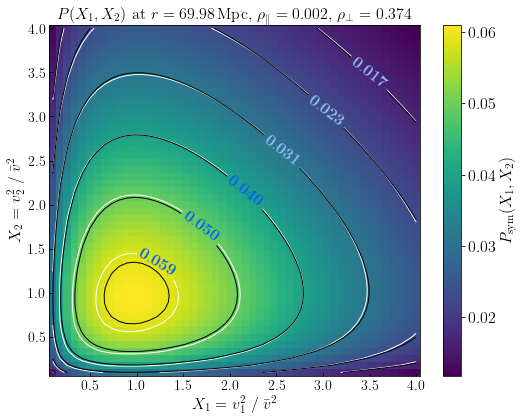

In [23]:
P_slice = P_X_Y_arr[0]
P_corrected_slice = P_X_Y_corrected_arr[0]

Xmesh, Ymesh = np.meshgrid(X_arr, Y_arr, indexing='ij')

fig, ax = plt.subplots(figsize=(7.5, 6))
pos_vals = P_slice[np.isfinite(P_slice) & (P_slice > 0)]
vmin = pos_vals.min() if len(pos_vals) > 0 else 1e-30
vmax = pos_vals.max() if len(pos_vals) > 0 else 1.0
im = ax.pcolormesh(Xmesh, Ymesh, P_corrected_slice, cmap='viridis',
                #    norm=LogNorm(vmin=vmin, vmax=vmax),
                   shading='auto')

# Use shared contour levels so both datasets are compared at identical values.
shared_levels = np.array([0.017, 0.023, 0.031, 0.040, 0.050, 0.059])
cs = ax.contour(Xmesh, Ymesh, P_slice, levels=shared_levels, colors='white', linewidths=1, alpha=1)
cs_corrected = ax.contour(Xmesh, Ymesh, P_corrected_slice, levels=shared_levels, colors='black', linewidths=1, alpha=1)

label_positions = [
    (3.5, 3.5),
    (3, 3),
    (2.5, 2.5),
    (2.2, 2.2),
    (1.6, 1.6),
    (1.1, 1.1),
]
assert len(label_positions) == len(cs.levels)

# With usetex=True, bold works reliably if encoded in the label string itself.
labels = ax.clabel(
    cs,
    inline=True,
    fontsize=16,
    fmt=lambda v: rf'$\mathbf{{{v:.3f}}}$',
    manual=label_positions,
)

label_colors = [
    "#96bcfe",
    "#96bcfe",
    "#96bcfe",
    "#045ffc",
    "#045ffc",
    "#045ffc",
]

for txt, color in zip(labels, label_colors):
    txt.set_color(color)

placeholder_labels = ax.clabel(
    cs_corrected,
    levels=shared_levels[:-1],
    inline=True,
    fmt=lambda v: rf'$\mathbf{{{v:.3f}}}$',
    manual=label_positions[:-1],
    fontsize=16,
)
placeholder_labels_ = ax.clabel(
    cs_corrected,
    levels=[shared_levels[-1]],
    inline=False,
    fmt=lambda v: rf'$\mathbf{{{v:.3f}}}$',
    manual=[label_positions[-1]],
    fontsize=16,
)

for t in placeholder_labels + placeholder_labels_:
    t.set_visible(False)

cb = plt.colorbar(im, ax=ax)
cb.ax.tick_params(labelsize=16)
cb.set_label(r'$P_{\mathrm{sym}}(X_1,X_2)$', fontsize=16)

ax.set_xlabel(r'$X_1 = v_1^2\;/\;\bar{v}^2$', fontsize=16)
ax.set_ylabel(r'$X_2 = v_2^2\;/\;\bar{v}^2$', fontsize=16)
ax.set_title(rf'$P(X_1,X_2)$ at $r = {rlist[rchoose]:.2f}\,\mathrm{{Mpc}}$'
             rf',  $\rho_{{\parallel}} = {rho_para_val:.3f}$,  $\rho_{{\perp}} = {rho_perp_val:.3f}$',
             fontsize=16)
ax.tick_params(axis='both', which='both', direction='in', labelsize=14)
plt.tight_layout()

In [24]:
X_fine = np.linspace(1e-6, 30, 300)
Y_fine = np.linspace(1e-6, 30, 300)

P_norm_check = P_X_Y(X_fine, Y_fine, sigma_vcb**2, rho_para_val, rho_perp_val)[0]

n_nan = np.sum(~np.isfinite(P_norm_check))
print(f"NaN/Inf count in P_norm_check: {n_nan} / {P_norm_check.size}")

norm = np.trapz(np.trapz(P_norm_check, Y_fine, axis=1), X_fine)
print(f"Normalization integral = {norm:.6f}  (should be 1)")

100%|██████████| 300/300 [04:15<00:00,  1.18it/s]

NaN/Inf count in P_norm_check: 0 / 90000
Normalization integral = 0.992818  (should be 1)
